<a href="https://colab.research.google.com/github/MarinaStepanova1709/PythonProject/blob/main/%D0%A2%D0%B5%D1%81%D1%82%D0%BE%D0%B2%D0%BE%D0%B5_%D0%94%D0%B8%D0%BA%D1%81%D0%B8_final_20260907.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Оценка эффективности акции.

1.   Определить, какие каналы привлечения (marketing_channel) наиболее
рентабельны с учётом стоимости привлечения (acquisition_cost) и долгосрочной ценности клиента (lifetime_value).

2. Выявить факторы, связанные с оттоком (churned = 1 для клиентов, у которых последняя покупка была >90 дней назад)
3. Разработать рекомендации по персонализации маркетинговых активностей на основе сегментов (segment) и поведения
4. Оценить окупаемость конкретных маркетинговых кампаний (acquisition_campaign) внутри платных каналов


In [1]:
import pandas as pd
import numpy as np
df = pd.read_excel('/content/drive/MyDrive/подготовка к собесу/Дикси/crm_marketing_dataset.xlsx')

In [2]:
# посмотрим что прочиталось из файла
df.head()

,customer_id,first_contact_date,marketing_channel,acquisition_campaign,country,device_type,total_orders,total_revenue,first_purchase_date,last_purchase_date,...,email_opened,clicks,acquisition_cost,avg_order_value,days_since_first_purchase,segment,cohort_month,lifetime_value,total_profit,roi
0,CUST_000001,2023-04-13,email,newsletter_welcome,Germany,mobile,3,308.386684,2023-04-17,2023-05-30,...,1,0,29.959874,102.795561,411.0,medium_value,2023-04,308.386684,278.426811,9.293324
1,CUST_000002,2024-03-11,email,newsletter_welcome,USA,desktop,1,99.994037,2024-03-19,2024-03-19,...,2,0,21.080200,99.994037,74.0,low_value,2024-03,99.994037,78.913837,3.743505
2,CUST_000003,2023-09-28,referral,refer_friend_20,Other,mobile,2,86.852343,2023-09-28,2023-10-11,...,0,0,41.813821,43.426171,247.0,low_value,2023-09,86.852343,45.038521,1.077120
3,CUST_000004,2023-04-17,organic,blog_referral,Canada,desktop,0,0.000000,NaN,NaN,...,0,0,0.000000,0.000000,NaN,non-buyer,2023-04,0.000000,0.000000,0.000000
4,CUST_000005,2023-03-13,email,abandoned_cart,Australia,desktop,0,0.000000,NaN,NaN,...,1,0,13.469230,0.000000,NaN,non-buyer,2023-03,0.000000,-13.469230,-1.000000


In [3]:
print("Размер таблицы:", df.shape)

print("\nСтолбцы:")
print(df.columns.tolist())





Размер таблицы: (100000, 21)

Столбцы:
['customer_id', 'first_contact_date', 'marketing_channel', 'acquisition_campaign', 'country', 'device_type', 'total_orders', 'total_revenue', 'first_purchase_date', 'last_purchase_date', 'churned', 'email_opened', 'clicks', 'acquisition_cost', 'avg_order_value', 'days_since_first_purchase', 'segment', 'cohort_month', 'lifetime_value', 'total_profit', 'roi']


In [ ]:
print("\nКоличество пропусков:")
missing = df.isna().sum()
display(missing[missing > 0].sort_values(ascending=False))


Количество пропусков:


,0
first_purchase_date,43104
last_purchase_date,43104
days_since_first_purchase,43104


In [ ]:
# отличаются ли lifetime_value и total_revenue
comparison = pd.DataFrame({
    "total_revenue": df["total_revenue"],
    "lifetime_value": df["lifetime_value"],
    "difference": df["lifetime_value"] - df["total_revenue"]
})

# строки где ["lifetime_value"] не равно ["total_revenue"]
comparison[comparison['difference'] > 0]

,total_revenue,lifetime_value,difference


В датасете lifetime_value равен накопленной выручке

# 1. Оценка рентабельности каналов привлечения
Цель: Найти каналы (marketing_channel) с наилучшим соотношением LTV (lifetime_value) и стоимости привлечения (acquisition_cost), а также посчитать общий ROI.

In [16]:


# Сгруппируем данные по каналам привлечения
channel_analysis = df.groupby('marketing_channel').agg(
    total_customers=('customer_id', 'count'),
    total_buyers=('total_orders', lambda x: (x > 0).sum()),
    avg_cac=('acquisition_cost', 'mean'),
    avg_ltv=('lifetime_value', 'mean'),
    total_revenue=('total_revenue', 'sum'),
    total_cost=('acquisition_cost', 'sum')
).reset_index()

# Считаем совокупный ROI и соотношение LTV к CAC
channel_analysis['total_profit'] = channel_analysis['total_revenue'] - channel_analysis['total_cost']
#  ARPPU (Выручка / Количество покупателей)
channel_analysis['arppu'] = np.where(
    channel_analysis['total_buyers'] > 0,
    channel_analysis['total_revenue'] / channel_analysis['total_buyers'],
    0
)
# roi нужно считать по агрегированным данным, а не обычным средним: клиенты имеют разный acquisition_cost.
channel_analysis['channel_roi'] = channel_analysis['total_profit'] / channel_analysis['total_cost']
channel_analysis['ltv_to_cac'] = channel_analysis['avg_ltv'] / channel_analysis['avg_cac']


print(channel_analysis.sort_values(by='channel_roi', ascending=False))


  marketing_channel  total_customers  total_buyers    avg_cac     avg_ltv  \
0            direct             9977          6929   0.000000  168.908704   
2           organic            25076         15176   0.000000  112.319746   
5          referral            14979          9782  30.006378  176.704853   
1             email            19950         11000  20.026929   94.351179   
4               ppc            10013          4995  49.985199   88.285230   
3       paid_social            20005          9014  50.030352   70.383689   

   total_revenue    total_cost  total_profit       arppu  channel_roi  \
0   1.685202e+06  0.000000e+00  1.685202e+06  243.210007          inf   
2   2.816530e+06  0.000000e+00  2.816530e+06  185.591062          inf   
5   2.646862e+06  4.494655e+05  2.197396e+06  270.584951     4.888910   
1   1.882306e+06  3.995372e+05  1.482769e+06  171.118730     3.711216   
4   8.840000e+05  5.005018e+05  3.834982e+05  176.976978     0.766227   
3   1.408026e+06  1.00

In [21]:
# заполняем нули - в бесплатных каналах
channel_analysis_clean = channel_analysis.replace([np.inf, -np.inf], np.nan).fillna(0)

styled_table = (channel_analysis_clean
    .sort_values(by='channel_roi', ascending=False)
    .style


    #  чем выше ROI, тем  зеленее цвет
    .background_gradient(subset=['channel_roi'], cmap='YlGn', text_color_threshold=0.4)

    # Из коробки: чем выше соотношение LTV/CAC, тем сочнее зеленый цвет
    .background_gradient(subset=['ltv_to_cac'], cmap='YlGn', text_color_threshold=0.4)
    # Подсвечиваем ARPPU: сразу увидим, где платящие клиенты самые «жирные»
    .background_gradient(subset=['arppu'], cmap='YlGn', text_color_threshold=0.4)
    # Красивое форматирование чисел
    .format({
        'avg_cac': '${:,.2f}', 'avg_ltv': '${:,.2f}',
        'channel_roi': '{:.2f}', 'ltv_to_cac': '{:.2f}x',
        'arppu': '${:,.2f}', 'avg_ltv': '${:,.2f}',
        'total_revenue': '{:,.0f}',
        'total_cost': '{:,.0f}',
        'total_profit': '{:,.0f}',
    })
)

styled_table


,marketing_channel,total_customers,total_buyers,avg_cac,avg_ltv,total_revenue,total_cost,total_profit,arppu,channel_roi,ltv_to_cac
5,referral,14979,9782,$30.01,$176.70,"2,646,862","449,466","2,197,396",$270.58,4.89,5.89x
1,email,19950,11000,$20.03,$94.35,"1,882,306","399,537","1,482,769",$171.12,3.71,4.71x
4,ppc,10013,4995,$49.99,$88.29,"884,000","500,502","383,498",$176.98,0.77,1.77x
3,paid_social,20005,9014,$50.03,$70.38,"1,408,026","1,000,857","407,169",$156.20,0.41,1.41x
0,direct,9977,6929,$0.00,$168.91,"1,685,202",0,"1,685,202",$243.21,0.00,0.00x
2,organic,25076,15176,$0.00,$112.32,"2,816,530",0,"2,816,530",$185.59,0.00,0.00x


# Итоги

На основе анализа окупаемости по каналам привлечения:

1. Наиболее рентабельным платным каналом является **Refferal** - реферальная программа : его ROI составляет около 489%. На каждый вложенный рубль канал приносит примерно 5,89 рубля LTV, из которых 4,89 рубля остаются после покрытия стоимости привлечения.
Значит аудитория привлечения была выбрана правильна.
Рекомендую масштабировать этот канал и протестировать новые механики рекомендаций, новые партнеры для реферальных программ

2. Канал **Email** на втором месте по окупаемости с ROI = 371.1%.
Обусловлено тем, что удержание и прогрев текущей базы обходится компании дешево, а долгосрочная ценность (LTV) этих клиентов находится на высоком уровне. Инвестиции в автоматизацию триггерных рассылок полностью оправданы.

3. Платный поиск (**PPC**) показывает сдержанный результат (ROI = 76.6%), в то время как таргетированная реклама (**Paid Social**) находится на грани окупаемости (ROI = 40.7%). LTV каналов также самые низкие. Низкие показатели относительно Email и Referral сигнализируют о высокой стоимости привлечения (CAC). Необходимо детально пересмотреть настройки таргетинга и креативы внутри конкретных кампаний.

4. Показатель ROI = 0% для каналов **Direct** и **Organic** обусловлен отсутствием прямых затрат на привлечение (acquisition_cost = 0) в рамках текущей модели учета. Однако каналы показывают высокие показатели LTV

#2. Выявить факторы, связанные с оттоком (churned = 1 для клиентов, у которых последняя покупка была >90 дней назад)

Для анализа оттока - исключим всех клиентов у кого не было покупок - они не привлеченные, а также оставим только тех клиентов у которых было не менее 90 дней наблюдения

In [ ]:
# какие столбцы есть - из них выбираю для категориальных признаков
df.columns

Index(['customer_id', 'first_contact_date', 'marketing_channel',
       'acquisition_campaign', 'country', 'device_type', 'total_orders',
       'total_revenue', 'first_purchase_date', 'last_purchase_date', 'churned',
       'email_opened', 'clicks', 'acquisition_cost', 'avg_order_value',
       'days_since_first_purchase', 'segment', 'cohort_month',
       'lifetime_value', 'total_profit', 'roi'],
      dtype='object')

In [ ]:

# Фильтруем: только покупатели, у которых с первой покупки прошло от 90 дней и более
df_mature = df[(df['total_orders'] > 0) & (df['days_since_first_purchase'] >= 90)].copy()

# Полный список ваших категориальных признаков
categorical_features = [
    "marketing_channel",
    "acquisition_campaign",
    "country",
    "device_type",
    "segment",
    "cohort_month"
]

In [29]:
# Проверяем долю оттока
churn = df_mature['churned'].value_counts().reset_index()
print(churn)
churn_rate = df_mature["churned"].mean()
print(f'\nОбщая доля оттока: {churn_rate}')

   churned  count
0        1  41456
1        0   5003

Общая доля оттока: 0.8923136528982544


In [27]:

# --- ФУНКЦИИ ДЛЯ АНАЛИЗА ОТТОКА ---
def churn_by_category(dataframe, column_name):
    """
    Функция группирует данные по признаку, считает долю оттока,
    средний чек и общее количество клиентов в разрезе.
    """
    stats = dataframe.groupby(column_name).agg(
        total_buyers=('customer_id', 'count'),
        avg_aov=('avg_order_value', 'mean'),
        churn_rate=('churned', 'mean'),

    ).reset_index()

    #  churn_rate в проценты
    stats['churn_rate'] = stats['churn_rate'] * 100

    # Сортируем по убыванию уровня оттока
    return stats.sort_values(by='churn_rate', ascending=False)

In [28]:


# ---  ВЫВОД ВСЕХ ТАБЛИЦ  ---
print(f"Анализ проводится по {len(df_mature)} зрелым покупателям.\n")
print("В столбце churn_rate указаны ПРОЦЕНТЫ (%) ушедших клиентов.")

for column in categorical_features:
    print(f"\n{"="*40}\nОтток по признаку: {column}\n{"="*40}")
    # Выводим топ-15 записей красиво
    display(churn_by_category(df_mature, column).head(15).round(2))


Анализ проводится по 46459 зрелым покупателям.

В столбце churn_rate указаны ПРОЦЕНТЫ (%) ушедших клиентов.

Отток по признаку: marketing_channel


,marketing_channel,total_buyers,avg_aov,churn_rate
3,paid_social,7363,101.72,92.94
4,ppc,4065,114.00,91.69
1,email,8922,108.43,91.57
2,organic,12418,100.94,88.19
0,direct,5675,116.46,86.68
5,referral,8016,124.57,85.39



Отток по признаку: acquisition_campaign


,acquisition_campaign,total_buyers,avg_aov,churn_rate
13,tiktok_challenge,2549,95.37,93.29
6,fb_summer_sale,2409,109.40,93.07
8,ig_stories,2405,100.76,92.43
0,abandoned_cart,2999,109.36,92.26
9,newsletter_welcome,3008,111.11,91.86
4,brand_keywords,2047,105.18,91.74
7,google_shopping,2018,122.94,91.63
14,weekly_digest,2915,104.70,90.57
11,organic_social,4133,96.26,88.53
2,blog_referral,4206,99.79,88.09



Отток по признаку: country


...

,device_type,total_buyers,avg_aov,churn_rate
1,mobile,25679,109.86,89.41
0,desktop,16198,110.04,89.07
2,tablet,4582,106.76,88.83



Отток по признаку: segment


,segment,total_buyers,avg_aov,churn_rate
1,low_value,29900,35.06,89.50
2,medium_value,12589,148.23,88.86
0,high_value,3970,548.69,88.36



Отток по признаку: cohort_month


,cohort_month,total_buyers,avg_aov,churn_rate
0,2023-01,3471,113.68,100.00
2,2023-03,3460,110.06,99.94
1,2023-02,3034,110.68,99.87
3,2023-04,3288,111.18,99.82
4,2023-05,3279,112.72,99.51
5,2023-06,3328,109.82,98.98
6,2023-07,3361,105.55,98.54
7,2023-08,3457,111.58,97.17
8,2023-09,3354,104.36,94.84
9,2023-10,3378,111.02,91.83


In [33]:
# Сравниваем числовые показатели
# Поведенческие факторы : заказы, выручка, средний чек, открытия писем и клики.
numeric_features = [
    "total_orders",
    "total_revenue",
    "acquisition_cost",
    "avg_order_value",
    "email_opened",
    "clicks",
    "lifetime_value"
]

numeric_comparison = (
    df_mature.groupby("churned")[numeric_features].agg(["mean"]).T
)

numeric_comparison.columns = ["active", "churned"]

display(numeric_comparison.round(2))

,,active,churned
total_orders,mean,3.92,2.29
total_revenue,mean,201.72,197.39
acquisition_cost,mean,18.49,21.72
avg_order_value,mean,58.89,115.74
email_opened,mean,0.46,0.59
clicks,mean,0.35,0.51
lifetime_value,mean,201.72,197.39


Итоги:
1. **Общая доля оттока** составляет **0.89**, т.е компания тратит огромные деньги на привлечение, но клиенты уходят навсегда почти сразу после первой покупки.
2. Наиболее показательным - является отток по когортам - в когортах - чей возраст более года - отток приближается к 100%.
3. **paid_social** и **ppc** - являются лидерами по оттоку 92.94% и	91.69 % соответственно. Это напрямую объясняет, почему у paid_social и ppc такой низкий ROI, который мы считали ранее. Высокий CAC просто не успевает окупиться, так как клиент уходит, не успев создать LTV.
4. У ушедших клиентов средний чек выше, чем у оставшихся (115.74 против 58.89), получается теряем самых прибыльных покупателей.

# 3. Разработать рекомендации по персонализации маркетинговых активностей на основе сегментов (segment) и поведения

In [4]:
# Посмотрим на профили сегментов
segment_profile = df.groupby('segment').agg(
    customers=('customer_id', 'count'),
    avg_orders=('total_orders', 'mean'),
    avg_revenue=('total_revenue', 'mean'),
    churn_rate=('churned', 'mean'),
    favorite_channel=('marketing_channel', lambda x: x.mode()[0]) # Самый частый канал
)
print(segment_profile.sort_values('avg_revenue', ascending = False))

              customers  avg_orders  avg_revenue  churn_rate favorite_channel
segment                                                                      
high_value         4902    2.594043  1014.564888    0.715626         referral
medium_value      15376    2.533949   267.438464    0.727562          organic
low_value         36618    2.426375    61.100959    0.730815          organic
non-buyer         43104    0.000000     0.000000    0.000000      paid_social


Видим большое число - non-buyer, клиентов, которые ничего не купили. Средний чек клиентов high_value - сильно больше medium_value. Самый частый канал траффика для high_value- refferal. Для medium_value и low_value - organic. НЕпокупатели чаще призодят из соцсетей - возиожно это нецелевой траффик, надо обратить на это внимание.

In [5]:

import matplotlib.pyplot as plt
import seaborn as sns

# --- Анализ распределения каналов по сегментам ---
# Считаем, сколько клиентов каждого сегмента пришло из каждого канала
channel_by_segment = df.groupby(['segment', 'marketing_channel']).agg(
    users_count=('customer_id', 'count'),
    total_rev=('total_revenue', 'sum'),
    avg_ltv=('lifetime_value', 'mean'),
    churn_rate=('churned', 'mean')
).reset_index()

# Считаем долю (процент) каждого канала внутри конкретного сегмента
segment_totals = df.groupby('segment')['customer_id'].count().reset_index().rename(columns={'customer_id': 'segment_total'})
channel_by_segment = channel_by_segment.merge(segment_totals, on='segment')
channel_by_segment['share_in_segment'] = channel_by_segment['users_count'] / channel_by_segment['segment_total']

print("--- Доли каналов внутри сегментов и их метрики ---")
print(channel_by_segment.sort_values(by=['segment', 'share_in_segment'], ascending=[True, False]).to_string(index=False))

--- Доли каналов внутри сегментов и их метрики ---
     segment marketing_channel  users_count    total_rev     avg_ltv  churn_rate  segment_total  share_in_segment
  high_value          referral         1333 1.307734e+06  981.046072    0.684171           4902          0.271930
  high_value           organic         1139 1.155592e+06 1014.566775    0.735733           4902          0.232354
  high_value            direct          806 8.309312e+05 1030.932024    0.692308           4902          0.164423
  high_value             email          759 7.270060e+05  957.847154    0.744401           4902          0.154835
  high_value       paid_social          516 5.565273e+05 1078.541344    0.728682           4902          0.105263
  high_value               ppc          349 3.956066e+05 1133.543192    0.742120           4902          0.071195
   low_value           organic        10073 6.154090e+05   61.094908    0.722526          36618          0.275083
   low_value             email       

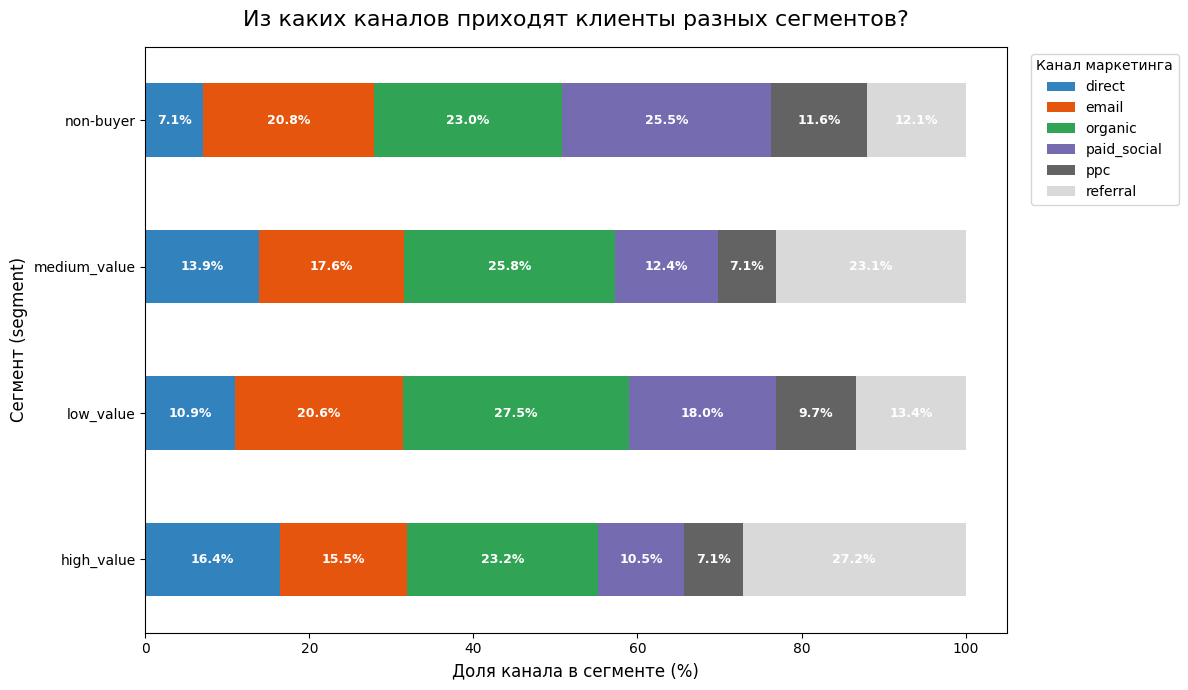

In [48]:
# Готовим данные для построения   графика
pivot_channels = df.pivot_table(
    index='segment',
    columns='marketing_channel',
    values='customer_id',
    aggfunc='count',
    fill_value=0
)

# Переводим абсолютные значения в проценты
pivot_channels_percentage = pivot_channels.div(pivot_channels.sum(axis=1), axis=0) * 100

# Строим график
fig, ax = plt.subplots(figsize=(12, 7))
pivot_channels_percentage.plot(
    kind='barh',
    stacked=True,
    cmap='tab20c', #
    ax=ax
)

# Настройка эстетики графика
ax.set_title('Из каких каналов приходят клиенты разных сегментов?', fontsize=16, pad=15)
ax.set_xlabel('Доля канала в сегменте (%)', fontsize=12)
ax.set_ylabel('Сегмент (segment)', fontsize=12)
ax.legend(title='Канал маркетинга', bbox_to_anchor=(1.02, 1), loc='upper left')

# Добавляем текстовые подписи процентов внутрь баров (для читаемости)
for p in ax.patches:
    width = p.get_width()
    if width > 5: # пишем только если сегмент больше 5%, чтобы текст не слипался
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        ax.text(x, y, f'{width:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

##Из каких каналов приходят клиенты разных сегментов?

1. Видим что в сегменте high_value доля organic или referral (реферальная программа) аномально высокая. При этом стоимость привлечения (acquisition_cost) там низкая, а LTV большой.Рекомендация: Усилить SEO-оптимизацию и перезапустить реферальную программу («Приведи друга — получи бонус»), так как этот канал генерирует высокий чек.

2. Платные каналы (ppc, paid_social) занимают 30%+ в сегменте некупивших (non-buyer) или тех кто приносит мало денег (low_value). Деньги тратятся, клики есть, но клиенты не задерживаются.Рекомендация: Персмотреть целевую аудиторию. Нужно найти конкретные убыточные кампании и перенастроить креативы.

3. Из канала email приходит  15-20% трафика. Отличный дешевый канал привлечения. Нужно автоматизировать воронку: как только клиент из платного канала делает первую покупку, сразу подписывать его на рассылку, чтобы снизить риск оттока.

4. Высокая доля директ и органик - в сегменте high_value - говорит о том что продукт хороший и привлекает платежеспособных клиентов

In [51]:
# --- Поведенческий профиль ---

# Заполняем пропуски в поведении нулями, чтобы не ломать средние значения
df['email_opened'] = df['email_opened'].fillna(0)
df['clicks'] = df['clicks'].fillna(0)

# Группируем данные по сегментам и рассчитываем их поведенческий профиль
segment_behavior = df.groupby('segment').agg(
    total_users=('customer_id', 'count'),
    # Покупки
    avg_orders=('total_orders', 'mean'),
    avg_aov=('avg_order_value', 'mean'),
    # Вовлеченность (Маркетинг)
    avg_emails_opened=('email_opened', 'mean'),
    avg_clicks=('clicks', 'mean'),
    # Отток (считаем только для тех, кто совершал покупки)
    churn_rate=('churned', lambda x: x[df.loc[x.index, 'total_orders'] > 0].mean() * 100),
    # Самое популярное устройство в сегменте (мода)
    favorite_device=('device_type', lambda x: x.mode()[0] if not x.mode().empty else 'unknown')
).reset_index()

# Округляем до 2 знаков для аккуратности
print("=== ПОВЕДЕНЧЕСКИЙ ПРОФИЛЬ СЕГМЕНТОВ ДЛЯ ПЕРСОНАЛИЗАЦИИ ===")
display(segment_behavior.round(2))


=== ПОВЕДЕНЧЕСКИЙ ПРОФИЛЬ СЕГМЕНТОВ ДЛЯ ПЕРСОНАЛИЗАЦИИ ===


,segment,total_users,avg_orders,avg_aov,avg_emails_opened,avg_clicks,churn_rate,favorite_device
0,high_value,4902,2.59,553.29,0.46,0.34,71.56,mobile
1,low_value,36618,2.43,34.94,0.62,0.56,73.08,mobile
2,medium_value,15376,2.53,148.93,0.52,0.39,72.76,mobile
3,non-buyer,43104,0.00,0.00,0.62,0.74,NaN,mobile




1.  У **non-buyer** - самый высокий уровень кликов. Они кликают по рекламе чаще всех, они открывают ваши письма, но в самый последний момент уходят без покупки. Проблема не в маркетинге — маркетологи приводят идеальную, теплую аудиторию. Проблема в продукте, цене или техническом барьере. Или в том что предложение не соответствует действительности. **Рекомендации** - проверить продукт
2.  **high_value**	и **medium_value** -клиенты «слепы» к стандартному маркетингу. Они игнорируют  email-рассылки и баннеры. Они покупают потому, что знают ценность продукта, но при этом у них огромный отток — 71.56%! **Рекомендации** - не спамить их стандартными письмами, которые они не открывают

3. Абсолютно во всех сегментах лидируют смартфоны favorite_device = mobile


# 4. Оценка окупаемости конкретных маркетинговых кампаний (acquisition_campaign) внутри платных каналов.


In [49]:

import matplotlib.pyplot as plt
import seaborn as sns

# Заменяем возможные пропуски в кликах нулями (для органики или директа их может не быть)
df['clicks'] = df['clicks'].fillna(0)

# 1. Группируем данные абсолютно по ВСЕМ каналам и кампаниям
all_campaign_stats = df.groupby(['marketing_channel', 'acquisition_campaign']).agg(
    total_users=('customer_id', 'count'),
    total_buyers=('total_orders', lambda x: (x > 0).sum()),
    total_clicks=('clicks', 'sum'),
    total_cost=('acquisition_cost', 'sum'),
    total_revenue=('total_revenue', 'sum'),
    avg_ltv=('lifetime_value', 'mean')
).reset_index()

# 2. Рассчитываем ключевые метрики эффективности (KPI)
# Если у канала (например, direct или organic) клики равны 0, conversion_rate и cpc заменятся на 0
all_campaign_stats['conversion_rate'] = np.where(all_campaign_stats['total_clicks'] > 0,
                                                 all_campaign_stats['total_users'] / all_campaign_stats['total_clicks'], 0)

all_campaign_stats['cpc'] = np.where(all_campaign_stats['total_clicks'] > 0,
                                     all_campaign_stats['total_cost'] / all_campaign_stats['total_clicks'], 0)

# Считаем ROI. Если cost = 0, ROI будет равен 0 (как указано в описании вашего задания)
all_campaign_stats['roi'] = np.where(all_campaign_stats['total_cost'] > 0,
                                     (all_campaign_stats['total_revenue'] - all_campaign_stats['total_cost']) / all_campaign_stats['total_cost'], 0)

# Сортируем от самых убыточных к самым прибыльным по всему датасету
all_campaign_stats = all_campaign_stats.sort_values(by='roi', ascending=True)

print("--- ПОЛНЫЙ АНАЛИЗ ВСЕХ МАРКЕТИНГОВЫХ КАМПАНИЙ В ДАТАСЕТЕ ---")
print(all_campaign_stats.to_string(index=False))


--- ПОЛНЫЙ АНАЛИЗ ВСЕХ МАРКЕТИНГОВЫХ КАМПАНИЙ В ДАТАСЕТЕ ---
marketing_channel acquisition_campaign  total_users  total_buyers  total_clicks    total_cost  total_revenue    avg_ltv  conversion_rate       cpc      roi
           direct             bookmark         4984          3450             0      0.000000   8.397025e+05 168.479630         0.000000  0.000000 0.000000
           direct          direct_type         4993          3479             0      0.000000   8.454997e+05 169.337004         0.000000  0.000000 0.000000
          organic       organic_search         8350          5016             0      0.000000   9.367021e+05 112.179897         0.000000  0.000000 0.000000
          organic        blog_referral         8411          5086             0      0.000000   9.428411e+05 112.096196         0.000000  0.000000 0.000000
          organic       organic_social         8315          5074             0      0.000000   9.369867e+05 112.686315         0.000000  0.000000 0.000000
   

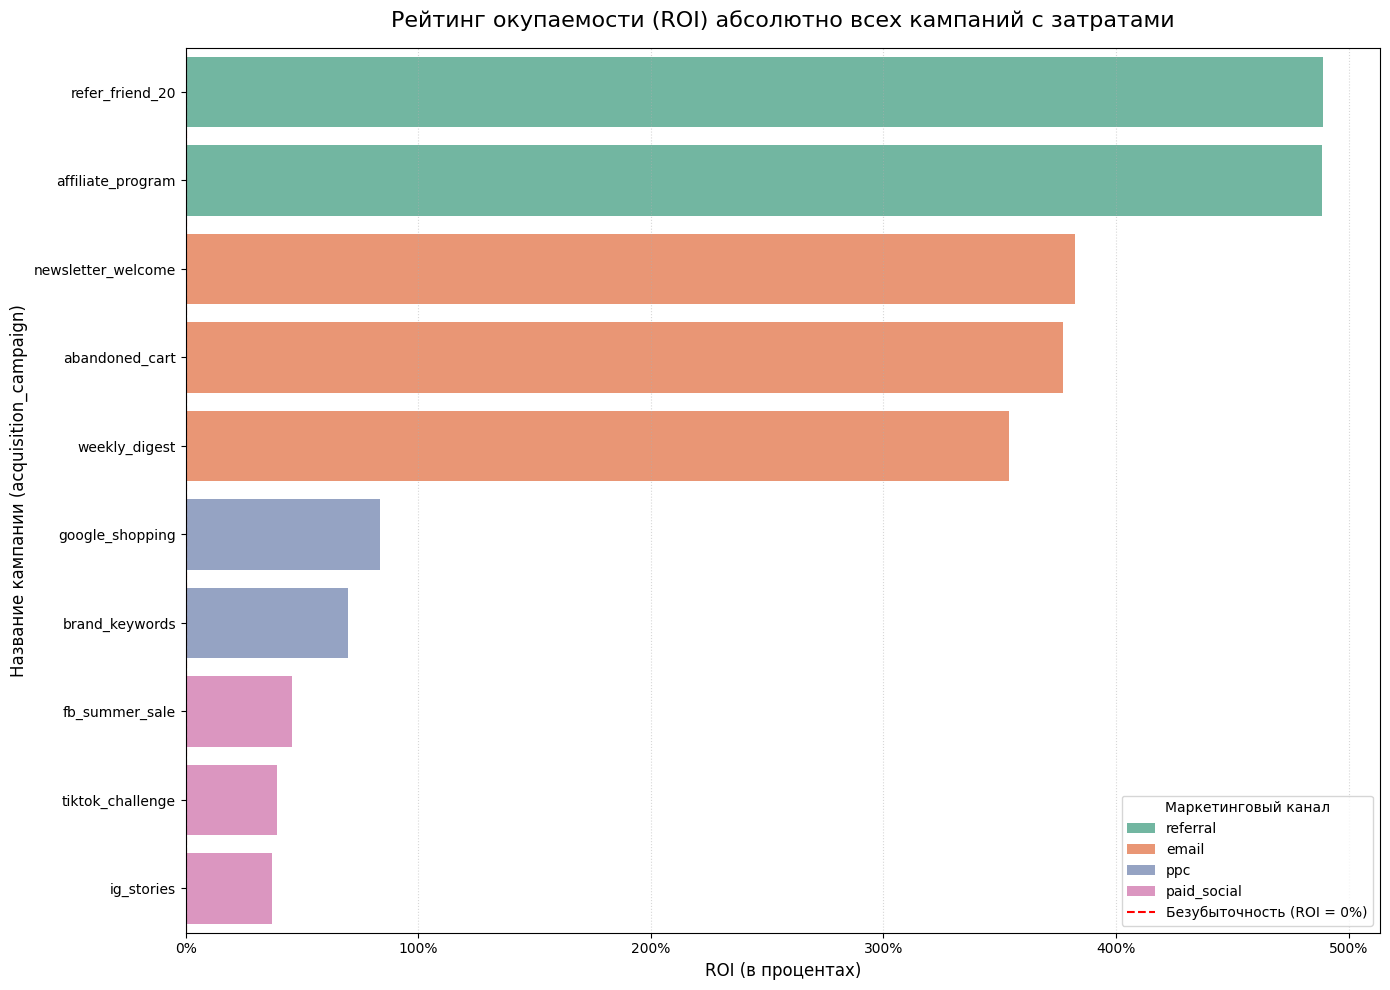

In [50]:
# Нам нужны только те кампании, где были хоть какие-то затраты, чтобы график ROI имел смысл
plot_all_data = all_campaign_stats[all_campaign_stats['total_cost'] > 0].sort_values(by='roi', ascending=False)

plt.figure(figsize=(14, 10))

# Строим горизонтальный график, где цвета разделены по маркетинговым каналам
sns.barplot(
    data=plot_all_data,
    x='roi',
    y='acquisition_campaign',
    hue='marketing_channel',
    dodge=False, # чтобы бары не смещались относительно оси Y
    palette='Set2'
)

# Добавляем линию безубыточности (ROI = 0)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Безубыточность (ROI = 0%)')

# Настройки графика
plt.title('Рейтинг окупаемости (ROI) абсолютно всех кампаний с затратами', fontsize=16, pad=15)
plt.xlabel('ROI (в процентах)', fontsize=12)
plt.ylabel('Название кампании (acquisition_campaign)', fontsize=12)
plt.legend(title='Маркетинговый канал', loc='lower right')

# Форматируем ось X в проценты
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()




### Анализ оценки окупаемости конкретных маркетинговых кампаний

1. Кампании: refer_friend_20 (ROI = 489.0%) и affiliate_program (ROI = 488.7%). Это абсолютно лучшие кампании в портфеле. Каждая из них приносит компании более 1.32 млн выручки. Здесь зафиксирован самый высокий средний LTV ($176.7). Привлечённые через рекомендации клиенты имеют максимальную ценность для бизнеса.

**Рекомендация:** Масштабировать. Выделять дополнительные бюджеты. Протестировать новые реферальные триггеры, так как канал обладает колоссальным запасом прочности по окупаемости.

2. **Канал Email** Кампании: newsletter_welcome (ROI = 382.3%), abandoned_cart (ROI = 377.0%) и weekly_digest (ROI = 354.2%).
Кампании показывают хорошую  окупаемость. При этом приветственные письма (newsletter_welcome) и триггер брошенной корзины (abandoned_cart) лидируют по качеству аудитории: они приносят клиентов с LTV более $95–$97.

**Рекомендация:** Усилить автоматизацию. Конверсия в клики по этим кампаниям в датасете не учитывается напрямую (равна 0), но финансовый результат доказывает, что удержание базы работает эффективно. Рекомендую протестировать и внедрить дополнительные поведенческие триггеры (например, реактивация через 45 дней засыпания).

3. **Канал PPC**
Кампании: google_shopping (ROI = 83.6%) и brand_keywords (ROI = 69.6%). Обе кампании показывают умеренную окупаемость. Они имеют стабильную конверсию из клика в лид на уровне ~50%.  При этом товарная реклама (google_shopping) привлекает более ценных клиентов (LTV = $92.2) по сравнению с брендовыми ключами (LTV = $84.4).

**Рекомендация:** Кампании прибыльны, но требуют постоянного контроля, чтобы их ROI не ушел в минус.

=========================================================================================================

# Общий вывод. Оценка эффективности акции.

### 1. Рентабельность каналов
Абсолютные лидеры: Канал Referral (ROI = 489%) и Email (ROI = 371.1%). Они обеспечивают максимальную маржинальность и наилучшее соотношение LTV к CAC. При этом реферальные программы приводят самых лучших платящих клиентов с максимальным показателем ARPPU и LTV (~$176).Платный трафик на грани:  PPC показывает умеренную доходность (ROI = 76.6%), в то время как таргетированная реклама Paid Social (ROI = 40.7%) едва окупает затраты из-за высокой стоимости привлечения.

### 2. Факторы и динамика оттока

Для точности расчёта была сформирована когорта  покупателей с окном наблюдения не менее 90 дней с момента первой покупки.
Общий уровень оттока составляет катастрофические 89%. Бизнес полностью зависит от постоянного притока новых пользователей.Главные маркеры оттока: Платные каналы — Paid Social (отток 92.94%) и PPC (отток 91.69%). Креативы привлекают разовых покупателей, которые исчезают сразу после первой транзакции.Выгорание базы: В когортах, чей возраст превышает 12 месяцев, отток приближается к 100%. Удержание (Retention)  в компании отсутствует.


### 3. Рекомендации по персонализации маркетинговых активностей на основе сегментов
Сегмент Non-buyer (43k лидов): Имеют высокую вовлеченность (клики 0.74, открытия писем 0.62), но нулевую конверсию. Требуется разобраться с тем что мешает конверсии в заказ. Возможно, следует внедрить персонализированные welcome-скидки на первый заказ.

Сегмент High-value (4.9k клиентов): Приносят большой чек ($553.29), но полностью игнорируют стандартный маркетинг (худший показатель открытий писем — 0.46). Рекомендовано исключить их из общего спама и перевести на закрытый клуб лояльности с коммуникацией исключительно через персональные push-уведомления или мессенджеры.

Сегменты Medium & Low-value (52k клиентов): Покупают 1–2 раза и уходят. Их высокую открываемость писем (до 0.62) нужно использовать для автоматических триггерных писем с кросс-сейлом (сопутствующие товары) в течение 14 дней после первой покупки.

### 4. Окупаемость конкретных маркетинговых кампаний (acquisition_campaign) внутри платных каналов

Точки роста и оптимизации:
Приоритет для привлечения новых клиентов: канал referral, кампании newsletter_welcome , abandoned_cart. Увеличиваем канал - пока есть куда расти

Приоритет для инвестиций: **Уменьшение оттока**. Кампании newsletter_welcome (ROI = 382.3%) и refer_friend_20 (ROI = 489.0%) . Сюда необходимо перенаправлять маркетинговый бюджет в первую очередь.

Кампании в соцсетях требуют особого внимания: ig_stories (ROI = 37.1%) и tiktok_challenge (ROI = 39.1%). Они генерируют самый низкий LTV в компании (68–69). Рекомендуется пересмотреть текущие креативы, так как они работают на грани окупаемости и приводят нецелевой трафик.
